# ¡Llena ese carrito!

# Introducción

Instacart es una plataforma de entregas de comestibles donde la clientela puede registrar un pedido y hacer que se lo entreguen, similar a Uber Eats y Door Dash.
El conjunto de datos que te hemos proporcionado tiene modificaciones del original. Redujimos el tamaño del conjunto para que tus cálculos se hicieran más rápido e introdujimos valores ausentes y duplicados. Tuvimos cuidado de conservar las distribuciones de los datos originales cuando hicimos los cambios.

Debes completar tres pasos. Para cada uno de ellos, escribe una breve introducción que refleje con claridad cómo pretendes resolver cada paso, y escribe párrafos explicatorios que justifiquen tus decisiones al tiempo que avanzas en tu solución.  También escribe una conclusión que resuma tus hallazgos y elecciones.


## Diccionario de datos

Hay cinco tablas en el conjunto de datos, y tendrás que usarlas todas para hacer el preprocesamiento de datos y el análisis exploratorio de datos. A continuación se muestra un diccionario de datos que enumera las columnas de cada tabla y describe los datos que contienen.

- `instacart_orders.csv`: cada fila corresponde a un pedido en la aplicación Instacart.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'user_id'`: número de ID que identifica de manera única la cuenta de cada cliente.
    - `'order_number'`: el número de veces que este cliente ha hecho un pedido.
    - `'order_dow'`: día de la semana en que se hizo el pedido (0 si es domingo).
    - `'order_hour_of_day'`: hora del día en que se hizo el pedido.
    - `'days_since_prior_order'`: número de días transcurridos desde que este cliente hizo su pedido anterior.
- `products.csv`: cada fila corresponde a un producto único que pueden comprar los clientes.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'product_name'`: nombre del producto.
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
- `order_products.csv`: cada fila corresponde a un artículo pedido en un pedido.
    - `'order_id'`: número de ID que identifica de manera única cada pedido.
    - `'product_id'`: número ID que identifica de manera única cada producto.
    - `'add_to_cart_order'`: el orden secuencial en el que se añadió cada artículo en el carrito.
    - `'reordered'`: 0 si el cliente nunca ha pedido este producto antes, 1 si lo ha pedido.
- `aisles.csv`
    - `'aisle_id'`: número ID que identifica de manera única cada categoría de pasillo de víveres.
    - `'aisle'`: nombre del pasillo.
- `departments.csv`
    - `'department_id'`: número ID que identifica de manera única cada departamento de víveres.
    - `'department'`: nombre del departamento.

# Paso 1. Descripción de los datos

Lee los archivos de datos (`/datasets/instacart_orders.csv`, `/datasets/products.csv`, `/datasets/aisles.csv`, `/datasets/departments.csv` y `/datasets/order_products.csv`) con `pd.read_csv()` usando los parámetros adecuados para leer los datos correctamente. Verifica la información para cada DataFrame creado.


## Plan de solución

Escribe aquí tu plan de solución para el Paso 1. Descripción de los datos.
Importar librerías necesarias
Comenzaré importando las bibliotecas requeridas para el análisis, principalmente pandas para el manejo de datos.

Leer los conjuntos de datos en DataFrames
Utilizaré pd.read_csv() para cargar los cinco archivos CSV:

instacart_orders.csv

products.csv

aisles.csv

departments.csv

order_products.csv
Evaluaré si necesitan parámetros adicionales como sep, dtype, o encoding.

Mostrar información general de cada DataFrame
Ejecutaré DataFrame.info(show_counts=True) en cada conjunto para revisar:

Número de filas y columnas

Tipos de datos

Cantidad de valores no nulos

Visualizar algunas filas de cada DataFrame
Usaré head() para observar las primeras filas y validar que los datos fueron leídos correctamente.

Comentar observaciones relevantes
Anotaré en celdas Markdown cualquier detalle importante detectado, como:

Presencia de valores ausentes

Columnas con tipos de datos inadecuados

Posibles duplicados o inconsistencias

Este paso servirá como base para identificar las tareas de limpieza y transformación necesarias en el siguiente paso.


In [72]:
# importar librerías
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', None)
sns.set(style='whitegrid')


In [73]:
# leer conjuntos de datos en los DataFrames
base_path = '/datasets/'
orders = pd.read_csv(base_path + 'instacart_orders.csv', sep=';')
products = pd.read_csv(base_path + 'products.csv', sep=';')
aisles = pd.read_csv(base_path + 'aisles.csv', sep=';')
departments = pd.read_csv(base_path + 'departments.csv', sep=';')
order_products = pd.read_csv(base_path + 'order_products.csv', sep=';')

In [74]:
# mostrar información del DataFrame
print("Información de 'orders':")
print(orders.info(show_counts=True))
print(orders.head(), "\n")

Información de 'orders':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 478967 entries, 0 to 478966
Data columns (total 6 columns):
 #   Column                  Non-Null Count   Dtype  
---  ------                  --------------   -----  
 0   order_id                478967 non-null  int64  
 1   user_id                 478967 non-null  int64  
 2   order_number            478967 non-null  int64  
 3   order_dow               478967 non-null  int64  
 4   order_hour_of_day       478967 non-null  int64  
 5   days_since_prior_order  450148 non-null  float64
dtypes: float64(1), int64(5)
memory usage: 21.9 MB
None
   order_id  user_id  order_number  order_dow  order_hour_of_day  \
0   1515936   183418            11          6                 13   
1   1690866   163593             5          5                 12   
2   1454967    39980             4          5                 19   
3   1768857    82516            56          0                 20   
4   3007858   196724             2   

In [75]:
# mostrar información del DataFrame
print("Información de 'products':")
print(products.info(show_counts=True))
print(products.head(), "\n")

Información de 'products':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49694 entries, 0 to 49693
Data columns (total 4 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   product_id     49694 non-null  int64 
 1   product_name   48436 non-null  object
 2   aisle_id       49694 non-null  int64 
 3   department_id  49694 non-null  int64 
dtypes: int64(3), object(1)
memory usage: 1.5+ MB
None
   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3      

In [76]:
# mostrar información del DataFrame
print("Información de 'aisles':")
print(aisles.info(show_counts=True))
print(aisles.head(), "\n")

Información de 'aisles':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 134 entries, 0 to 133
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   aisle_id  134 non-null    int64 
 1   aisle     134 non-null    object
dtypes: int64(1), object(1)
memory usage: 2.2+ KB
None
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation 



In [77]:
# mostrar información del DataFrame
print("Información de 'departments':")
print(departments.info(show_counts=True))
print(departments.head(), "\n")

Información de 'departments':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21 entries, 0 to 20
Data columns (total 2 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   department_id  21 non-null     int64 
 1   department     21 non-null     object
dtypes: int64(1), object(1)
memory usage: 464.0+ bytes
None
   department_id department
0              1     frozen
1              2      other
2              3     bakery
3              4    produce
4              5    alcohol 



In [78]:
# mostrar información del DataFrame
print("Información de 'order_products':")
print(order_products.info(show_counts=True))
print(order_products.head(), "\n")

Información de 'order_products':
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4545007 entries, 0 to 4545006
Data columns (total 4 columns):
 #   Column             Non-Null Count    Dtype  
---  ------             --------------    -----  
 0   order_id           4545007 non-null  int64  
 1   product_id         4545007 non-null  int64  
 2   add_to_cart_order  4544171 non-null  float64
 3   reordered          4545007 non-null  int64  
dtypes: float64(1), int64(3)
memory usage: 138.7 MB
None
   order_id  product_id  add_to_cart_order  reordered
0   2141543       11440               17.0          0
1    567889        1560                1.0          1
2   2261212       26683                1.0          1
3    491251        8670               35.0          1
4   2571142        1940                5.0          1 



## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 1. Descripción de los datos.

Carga exitosa de los datos
Todos los archivos fueron leídos correctamente utilizando pandas. Las estructuras generales de los DataFrames coinciden con el diccionario de datos proporcionado.

Tamaño y estructura

orders contiene información sobre cada pedido y cliente.

products, aisles y departments ofrecen detalles sobre los productos y su clasificación.

order_products relaciona pedidos con productos específicos y contiene una gran cantidad de registros (como se esperaba, ya que cada pedido puede contener varios productos).

Tipos de datos
La mayoría de las columnas tienen tipos de datos adecuados (enteros para IDs, cadenas para nombres). No obstante, algunas columnas podrían requerir conversión para optimización futura.

Valores ausentes y duplicados
Se detectaron algunas columnas con valores nulos, especialmente en days_since_prior_order en la tabla orders, lo cual tiene sentido para los primeros pedidos. Aún no se han tratado los valores faltantes ni los duplicados; esto se abordará en el Paso 2.

Visualización preliminar
La muestra (head()) de cada DataFrame confirma que las columnas están bien alineadas y que los datos parecen coherentes con lo esperado (por ejemplo, nombres de productos, IDs, horas, etc.).

Estas observaciones servirán como base para realizar el preprocesamiento de los datos en el siguiente paso, donde abordaremos la limpieza, detección de duplicados y manejo de valores faltantes.




# Paso 2. Preprocesamiento de los datos

Preprocesa los datos de la siguiente manera:

- Verifica y corrige los tipos de datos (por ejemplo, asegúrate de que las columnas de ID sean números enteros).
- Identifica y completa los valores ausentes.
- Identifica y elimina los valores duplicados.

Asegúrate de explicar qué tipos de valores ausentes y duplicados encontraste, cómo los completaste o eliminaste y por qué usaste esos métodos. ¿Por qué crees que estos valores ausentes y duplicados pueden haber estado presentes en el conjunto de datos?

## Plan de solución

Escribe aquí tu plan para el Paso 2. Preprocesamiento de los datos.

En este paso se realizará el preprocesamiento de los datos para asegurar que estén limpios, consistentes y listos para el análisis. Las acciones se dividirán en tres subetapas clave:

Verificación y corrección de tipos de datos:
Se revisarán los tipos de datos de cada columna para asegurarse de que sean adecuados. Por ejemplo, las columnas de ID deben ser de tipo entero, los nombres como texto (objeto), y las variables categóricas como enteros o strings. Si se detectan inconsistencias, se corregirán con astype().

Identificación y tratamiento de valores ausentes:
Se buscarán valores nulos en cada DataFrame. Luego se decidirá si deben ser rellenados (por ejemplo, con 0 o con una media) o eliminados, dependiendo del contexto de cada variable. Se justificará cada decisión tomada.

Detección y eliminación de duplicados:
Se identificarán filas duplicadas completas y, si no aportan información nueva o generan redundancia, se eliminarán con drop_duplicates() para evitar distorsionar los resultados del análisis.

Al finalizar estas etapas, los datos estarán listos para el análisis exploratorio del Paso 3.

## Encuentra y elimina los valores duplicados (y describe cómo tomaste tus decisiones).

### `orders` data frame

In [79]:
duplicados_orders = orders.duplicated()
print(f"Número de filas duplicadas en 'orders': {duplicados_orders.sum()}")

Número de filas duplicadas en 'orders': 15


¿Tienes líneas duplicadas? Si sí, ¿qué tienen en común?

In [80]:
import pandas as pd

# Leer el archivo orders con el separador correcto (;)
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')

# Verificar las columnas para asegurarnos que están correctas
print("Columnas en orders:", orders.columns)

# Encontrar filas duplicadas en el DataFrame orders
duplicados_orders = orders[orders.duplicated()]

# Mostrar las primeras filas duplicadas para análisis
print("Primeras filas duplicadas:")
display(duplicados_orders.head())

# Verificar si las filas duplicadas tienen las mismas columnas 'order_id' y 'user_id'
if 'order_id' in duplicados_orders.columns and 'user_id' in duplicados_orders.columns:
    conteo_duplicados = duplicados_orders.groupby(['order_id', 'user_id']).size().sort_values(ascending=False).head()
    print("Conteo de duplicados agrupados por order_id y user_id:")
    print(conteo_duplicados)
else:
    print("No se encontraron las columnas 'order_id' y 'user_id' en los datos duplicados.")

# Filtrar pedidos que se hicieron el miércoles (order_dow == 3) a las 2:00 a.m. (order_hour_of_day == 2)
miercoles_2am = orders[(orders['order_dow'] == 3) & (orders['order_hour_of_day'] == 2)]

# Mostrar los primeros registros encontrados
print("Pedidos realizados el miércoles a las 2:00 a.m.:")
display(miercoles_2am.head())

# Mostrar el número total de pedidos en ese filtro
print(f"Número total de pedidos realizados el miércoles a las 2:00 a.m.: {miercoles_2am.shape[0]}")



Columnas en orders: Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order'],
      dtype='object')
Primeras filas duplicadas:


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
145574,794638,50898,24,3,2,2.0
223105,2160484,107525,16,3,2,30.0
230807,1918001,188546,14,3,2,16.0
266232,1782114,106752,1,3,2,NaN
273805,1112182,202304,84,3,2,6.0


Conteo de duplicados agrupados por order_id y user_id:
order_id  user_id
391768    57671      1
408114    68324      1
467134    63189      1
794638    50898      1
1021560   53767      1
dtype: int64
Pedidos realizados el miércoles a las 2:00 a.m.:


,order_id,user_id,order_number,order_dow,order_hour_of_day,days_since_prior_order
4838,2766110,162084,41,3,2,16.0
5156,2190225,138285,18,3,2,11.0
15506,553049,58599,13,3,2,7.0
18420,382357,120200,19,3,2,11.0
24691,690242,77357,2,3,2,9.0


Número total de pedidos realizados el miércoles a las 2:00 a.m.: 121


¿Qué sugiere este resultado?

Sobre los duplicados:
No es necesario eliminar filas en el DataFrame orders por duplicados exactos. Sin embargo, la presencia de valores faltantes (NaN) en days_since_prior_order podría ser relevante para el análisis o para imputar datos más adelante.

Sobre los pedidos en horarios específicos:
El análisis por día y hora de pedidos puede ser muy útil para entender hábitos de consumo. Saber que hay 121 pedidos un miércoles a las 2:00 a.m. podría ayudar a planificar entregas o mejorar el servicio en horarios de baja demanda.

In [81]:
# Número de filas antes de eliminar duplicados
print(f"Filas antes de eliminar duplicados: {orders.shape[0]}")

# Eliminar duplicados exactos
orders_clean = orders.drop_duplicates()

# Guardar el DataFrame limpio en 'orders' para seguir trabajando
orders = orders_clean

# Número de filas después de eliminar duplicados
print(f"Filas después de eliminar duplicados: {orders_clean.shape[0]}")

# Guardar el DataFrame limpio en 'orders' para seguir trabajando
orders = orders_clean


Filas antes de eliminar duplicados: 478967
Filas después de eliminar duplicados: 478952


In [82]:
# Verificar si quedan filas duplicadas
duplicados_restantes = orders.duplicated().sum()
print(f"Número de filas duplicadas restantes en 'orders': {duplicados_restantes}")


Número de filas duplicadas restantes en 'orders': 0


In [83]:
# Vuelve a verificar únicamente si hay IDs duplicados de pedidos
# Verificar si hay order_id duplicados
order_id_duplicados = orders['order_id'].duplicated().sum()
print(f"Número de order_id duplicados en 'orders': {order_id_duplicados}")


Número de order_id duplicados en 'orders': 0


Describe brevemente tus hallazgos y lo que hiciste con ellos

Al analizar el conjunto de datos original, encontramos que existían filas duplicadas exactas en el DataFrame orders. Inicialmente, había 478,967 filas, y tras eliminar las filas duplicadas exactas, el número de filas disminuyó a 478,952, lo que indica que se eliminaron 15 filas duplicadas. Posteriormente, realizamos una verificación exhaustiva para asegurarnos de que no quedaran más filas duplicadas y confirmamos que el número de filas duplicadas restantes es cero.

Adicionalmente, verificamos la existencia de IDs de pedidos (order_id) duplicados, ya que cada pedido debe ser único. Los resultados mostraron que no hay order_id repetidos en el DataFrame limpio, lo cual es consistente con la integridad esperada del conjunto de datos.

Estas acciones aseguran que el DataFrame orders no contenga registros redundantes que puedan sesgar análisis posteriores o generar resultados incorrectos. La limpieza de duplicados es fundamental para garantizar la calidad y confiabilidad del análisis de datos.

### `products` data frame

In [84]:
# Revisar filas duplicadas en products
duplicados_products = products[products.duplicated()]

# Mostrar las primeras filas duplicadas si existen
print("Primeras filas duplicadas en products:")
display(duplicados_products.head())

# Cantidad total de filas duplicadas
num_duplicados_products = duplicados_products.shape[0]
print(f"Número total de filas duplicadas en products: {num_duplicados_products}")


Primeras filas duplicadas en products:


,product_id,product_name,aisle_id,department_id


Número total de filas duplicadas en products: 0


In [85]:
# Verificar duplicados en product_id
products = pd.read_csv('/datasets/products.csv', sep=';')
print(products.columns)
product_id_duplicados = products['product_id'].duplicated().sum()
print(f"Número de product_id duplicados en 'products': {product_id_duplicados}")


Index(['product_id', 'product_name', 'aisle_id', 'department_id'], dtype='object')
Número de product_id duplicados en 'products': 0


In [86]:
# Convertir los nombres de productos a mayúsculas para normalizar
products['product_name_upper'] = products['product_name'].str.upper()

# Verificar nombres duplicados (en mayúsculas)
nombres_duplicados = products['product_name_upper'].duplicated().sum()
print(f"Número de nombres de productos duplicados (ignorando mayúsculas/minúsculas): {nombres_duplicados}")

Número de nombres de productos duplicados (ignorando mayúsculas/minúsculas): 1361


In [87]:
# Revisa si hay nombres duplicados de productos no faltantes

# Filtrar productos con nombres no faltantes
products_notnull = products[products['product_name'].notnull()].copy()

# Convertir a mayúsculas para comparación homogénea usando .loc para evitar warning
products_notnull.loc[:, 'product_name_upper'] = products_notnull['product_name'].str.upper()

# Revisar cuántos nombres duplicados hay en los que no faltan datos
nombres_duplicados_no_faltantes = products_notnull['product_name_upper'].duplicated().sum()
print(f"Número de nombres duplicados de productos no faltantes: {nombres_duplicados_no_faltantes}")


Número de nombres duplicados de productos no faltantes: 104


Describe brevemente tus hallazgos y lo que hiciste con ellos.

No se encontraron filas duplicadas exactas en el conjunto de datos, lo que indica que no hay registros completamente repetidos.

Las columnas presentes son: product_id, product_name, aisle_id y department_id, que son las esperadas para este conjunto de datos.

No hay IDs de producto duplicados, por lo que cada producto tiene un identificador único.

Se encontraron 1361 nombres de productos duplicados si se ignoran diferencias entre mayúsculas y minúsculas. Esto sugiere que hay múltiples productos con nombres iguales o muy similares escritos con diferente formato.

Cuando se excluyen los productos con nombres faltantes, quedaron 104 nombres duplicados, lo que confirma que hay un número considerable de productos que podrían estar registrados varias veces con el mismo nombre o nombres muy parecidos.

### `departments` data frame

In [88]:
# Revisa si hay filas totalmente duplicadas

# Revisar si hay filas completamente duplicadas en 'departments'
duplicados_departments = departments.duplicated().sum()
print(f"Número total de filas duplicadas en 'departments': {duplicados_departments}")

# Si las hay, puedes verlas con:
if duplicados_departments > 0:
    display(departments[departments.duplicated()])
else:
    print("No se encontraron filas duplicadas en 'departments'.")


Número total de filas duplicadas en 'departments': 0
No se encontraron filas duplicadas en 'departments'.


In [89]:
# Revisa únicamente si hay IDs duplicadas de departamentos
#departments[['department_id', 'department']] = departments['department_id;department'].str.split(';', expand=True)
#departments.drop(columns=['department_id;department'], inplace=True)
#departments['department_id'] = departments['department_id'].astype(int)

department_id_duplicados = departments['department_id'].duplicated().sum()
print(f"Número de department_id duplicados en 'departments': {department_id_duplicados}")


Número de department_id duplicados en 'departments': 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Filas totalmente duplicadas:

Resultado: No se encontraron filas duplicadas.

Acción tomada: Ninguna, ya que no fue necesario eliminar datos.

IDs de departamento (department_id) duplicados:

Resultado: No hay IDs duplicados.

Acción tomada: Ninguna, los identificadores son únicos como se espera en una tabla de dimensiones.

Esto indica que la estructura del DataFrame departments es consistente, limpia y está lista para ser utilizada en análisis o para realizar uniones (joins) con otras tablas como products.

### `aisles` data frame

In [90]:
# Revisa si hay filas totalmente duplicadas
import pandas as pd

# Cargar el archivo con la ruta correcta
aisles = pd.read_csv('/datasets/aisles.csv')

# Revisar las columnas para confirmar el formato
print("Columnas en aisles:", aisles.columns)

# Separar la columna combinada 'aisle_id;aisle' en dos columnas distintas
aisles_split = aisles['aisle_id;aisle'].str.split(';', expand=True)
aisles_split.columns = ['aisle_id', 'aisle']

# Convertir aisle_id a entero para mejor manejo
aisles_split['aisle_id'] = aisles_split['aisle_id'].astype(int)

# Verificar si hay filas duplicadas en el DataFrame corregido
duplicados = aisles_split.duplicated().sum()
print(f"Número total de filas duplicadas en aisles: {duplicados}")

# Mostrar primeras filas para verificar
print(aisles_split.head())



Columnas en aisles: Index(['aisle_id;aisle'], dtype='object')
Número total de filas duplicadas en aisles: 0
   aisle_id                       aisle
0         1       prepared soups salads
1         2           specialty cheeses
2         3         energy granola bars
3         4               instant foods
4         5  marinades meat preparation


In [91]:
# Revisa únicamente si hay IDs duplicadas de pasillos
# Revisar duplicados en 'aisle_id'
aisle_id_duplicados = aisles_split['aisle_id'].duplicated().sum()
print(f"Número de aisle_id duplicados en 'aisles': {aisle_id_duplicados}")



Número de aisle_id duplicados en 'aisles': 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Inicialmente, la columna del DataFrame estaba combinada en una sola llamada 'aisle_id;aisle', por lo que se separó correctamente en dos columnas: aisle_id y aisle.

Se verificó que no hay filas duplicadas exactas en el DataFrame aisles.

Se comprobó que no hay valores duplicados en la columna aisle_id, es decir, cada pasillo tiene un identificador único.

Esto indica que los datos de pasillos están limpios y no presentan problemas de duplicidad que puedan afectar análisis posteriores.

### `order_products` data frame

In [92]:
# Revisa si hay filas totalmente duplicadas

import pandas as pd

# Cargar el archivo order_products
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

# Revisar si hay filas totalmente duplicadas
duplicados_totales = order_products.duplicated().sum()
print(f"Número total de filas duplicadas en order_products: {duplicados_totales}")



Número total de filas duplicadas en order_products: 0


In [93]:
# Vuelve a verificar si hay cualquier otro duplicado engañoso
# Revisar si hay filas totalmente duplicadas
duplicados_totales = order_products.duplicated().sum()
print(f"Número total de filas duplicadas en 'order_products': {duplicados_totales}")

# Revisar duplicados en combinaciones clave que deberían ser únicas, por ejemplo order_id + product_id
duplicados_clave = order_products.duplicated(subset=['order_id', 'product_id']).sum()
print(f"Número de duplicados en la combinación 'order_id' y 'product_id': {duplicados_clave}")

# Revisar duplicados en otras combinaciones importantes, como order_id + add_to_cart_order
duplicados_otro = order_products.duplicated(subset=['order_id', 'add_to_cart_order']).sum()
print(f"Número de duplicados en la combinación 'order_id' y 'add_to_cart_order': {duplicados_otro}")



Número total de filas duplicadas en 'order_products': 0
Número de duplicados en la combinación 'order_id' y 'product_id': 0
Número de duplicados en la combinación 'order_id' y 'add_to_cart_order': 766


Describe brevemente tus hallazgos y lo que hiciste con ellos.
No hay filas totalmente duplicadas en el DataFrame order_products, lo que indica que no existen registros idénticos exactos repetidos.

Tampoco hay duplicados en la combinación clave order_id y product_id, lo que sugiere que no hay productos repetidos en un mismo pedido.

Sin embargo, se encontraron 766 duplicados en la combinación order_id y add_to_cart_order. Esto indica que en algunos pedidos hay más de un producto con el mismo número de orden dentro del carrito, lo cual puede ser un error o simplemente un indicador de registros repetidos en el orden de agregación.

Realicé una revisión general de duplicados en todo el DataFrame para detectar filas totalmente idénticas.

Verifiqué duplicados en combinaciones claves importantes (order_id + product_id) para identificar productos repetidos en un mismo pedido.

Finalmente, analicé duplicados en la combinación order_id + add_to_cart_order para identificar inconsistencias en la secuencia de agregación de productos dentro de cada pedido.


## Encuentra y elimina los valores ausentes

Al trabajar con valores duplicados, pudimos observar que también nos falta investigar valores ausentes:

* La columna `'product_name'` de la tabla products.
* La columna `'days_since_prior_order'` de la tabla orders.
* La columna `'add_to_cart_order'` de la tabla order_productos.

### `products` data frame

In [94]:
# Encuentra los valores ausentes en la columna 'product_name'
import pandas as pd
products = pd.read_csv('/datasets/products.csv', sep=';') 
faltantes_product_name = products['product_name'].isnull().sum()
print(f"Número de valores ausentes en 'product_name' de products: {faltantes_product_name}")

Número de valores ausentes en 'product_name' de products: 1258


Describe brevemente cuáles son tus hallazgos.
Se detectaron 1258 valores ausentes en la columna product_name.

Esto indica que una proporción considerable de productos no tiene un nombre asignado, lo cual puede afectar análisis posteriores o tareas como la identificación y categorización de productos.

In [95]:
#  ¿Todos los nombres de productos ausentes están relacionados con el pasillo con ID 100?
# Filtrar los productos con product_name ausente
productos_sin_nombre = products[products['product_name'].isnull()]

# Verificar si todos los aisles_id de esos productos son 100
todos_aisle_100 = (productos_sin_nombre['aisle_id'] == 100).all()

print(f"¿Todos los productos sin nombre tienen aisle_id igual a 100? {todos_aisle_100}")


¿Todos los productos sin nombre tienen aisle_id igual a 100? True


Describe brevemente cuáles son tus hallazgos.

Encontré que todos los productos que tienen el nombre ausente (product_name faltante) pertenecen exclusivamente al pasillo con aisle_id 100. Esto sugiere que el problema de nombres faltantes está asociado únicamente con ese pasillo, lo que podría indicar un problema de registro o un conjunto específico de productos sin información completa en esa sección. Es un hallazgo importante para decidir si se deben revisar o limpiar esos datos de manera particular.

In [96]:
# ¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?
# Filtrar los productos con nombre ausente
productos_sin_nombre = products[products['product_name'].isnull()]

# Verificar si todos esos productos tienen department_id igual a 21
todos_en_departamento_21 = (productos_sin_nombre['department_id'] == 21).all()

print("¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21?", todos_en_departamento_21)


¿Todos los nombres de productos ausentes están relacionados con el departamento con ID 21? True


Describe brevemente cuáles son tus hallazgos.

Encontramos que todos los productos que no tienen nombre están asociados al departamento con ID 21. Esto sugiere que el problema de nombres ausentes no está distribuido al azar, sino que está concentrado en ese departamento específico. Por lo tanto, podría ser necesario investigar más a fondo ese departamento para entender por qué sus productos carecen de nombres o si hubo un error en la carga o registro de esos datos.

In [97]:
# Usa las tablas department y aisle para revisar los datos del pasillo con ID 100 y el departamento con ID 21.
import pandas as pd

# Cargar departments con ruta correcta
departments = pd.read_csv('/datasets/departments.csv')

# Revisar columnas para confirmar problema
print(departments.columns)  # Probablemente sale algo como: Index(['department_id;department'], dtype='object')

# Separar la columna combinada en dos columnas separadas
departments_split = departments['department_id;department'].str.split(';', expand=True)
departments_split.columns = ['department_id', 'department']
departments_split['department_id'] = departments_split['department_id'].astype(int)

# Ahora sí filtrar el departamento con department_id == 21
departamento_21 = departments_split[departments_split['department_id'] == 21]

print("Datos del departamento con department_id = 21:")
print(departamento_21)
 

Index(['department_id;department'], dtype='object')
Datos del departamento con department_id = 21:
    department_id department
20             21    missing


Describe brevemente cuáles son tus hallazgos.

Los productos que no tienen nombre están todos asociados al departamento con ID 21, cuyo nombre es "missing", lo que indica que esos productos carecen de una categoría definida. Además, estos productos también están vinculados al pasillo con ID 100, lo que sugiere que están agrupados en una sección específica sin información completa. Esto refleja posibles datos faltantes o no registrados correctamente en el sistema, lo cual es importante considerar para la limpieza y mejora de la calidad de los datos.

In [98]:
# Completa los nombres de productos ausentes con 'Unknown'
products['product_name'] = products['product_name'].fillna('Unknown')
faltantes_product_name = products['product_name'].isnull().sum()
print(f"Número de valores ausentes en 'product_name' después de rellenar: {faltantes_product_name}")

Número de valores ausentes en 'product_name' después de rellenar: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Encontré que inicialmente había 1,258 valores ausentes en la columna 'product_name' del dataframe products, todos relacionados con el pasillo con ID 100 y el departamento con ID 21, que resultaron ser categorías “missing” o desconocidas.

Para asegurar la integridad de los datos y evitar problemas en análisis posteriores, completé esos valores ausentes con el texto 'Unknown'. Después de esta acción, ya no quedan valores ausentes en dicha columna, lo que garantiza que la información esté completa para futuros procesos o modelos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
La manera de encontrar los valores ausentes y reemplazarlos con un valor generico es correcta
</div>


### `orders` data frame

In [99]:
# Encuentra los valores ausentes
import pandas as pd

orders = pd.read_csv('/datasets/instacart_orders.csv')

# Conteo de valores ausentes por columna en orders
faltantes_orders = orders.isnull().sum()
print(faltantes_orders)

order_id;user_id;order_number;order_dow;order_hour_of_day;days_since_prior_order    0
dtype: int64


In [100]:
# ¿Hay algún valor ausente que no sea el primer pedido del cliente?
import pandas as pd

# Leer el archivo con separador correcto
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')

# Revisar las columnas para confirmar
print(orders.columns)

# Filtrar filas donde 'days_since_prior_order' es NaN pero el número de pedido NO es 1
faltantes_no_primer_pedido = orders[(orders['days_since_prior_order'].isnull()) & (orders['order_number'] != 1)]

print(f"Cantidad de valores ausentes en 'days_since_prior_order' que NO corresponden al primer pedido: {len(faltantes_no_primer_pedido)}")



Index(['order_id', 'user_id', 'order_number', 'order_dow', 'order_hour_of_day',
       'days_since_prior_order'],
      dtype='object')
Cantidad de valores ausentes en 'days_since_prior_order' que NO corresponden al primer pedido: 0


Describe brevemente tus hallazgos y lo que hiciste con ellos.

Al analizar el dataframe orders, primero confirmé que los nombres de columnas se leyeron correctamente usando el separador adecuado (;). Luego, investigué los valores ausentes en la columna days_since_prior_order, que indica cuántos días han pasado desde el pedido anterior.

Encontré que todos los valores ausentes en esta columna corresponden únicamente al primer pedido de cada cliente (order_number == 1). No existen valores ausentes para pedidos posteriores, lo cual tiene sentido, ya que no hay un pedido previo para el primero y por eso esa información no está disponible.

Esto indica que los datos están consistentes en cuanto a la columna days_since_prior_order, y no se requiere un manejo especial para valores ausentes en pedidos posteriores.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho!<br/>
Buena manera de revisar los datos y encontrar que no hay ausentes que no sean un primer pedido
</div>


### `order_products` data frame

In [101]:
# Encuentra los valores ausentes
import pandas as pd

order_products = pd.read_csv('/datasets/order_products.csv', sep=';')


# Verifica los valores ausentes
faltantes_order_products = order_products.isnull().sum()
print(faltantes_order_products)


order_id               0
product_id             0
add_to_cart_order    836
reordered              0
dtype: int64


In [102]:
# ¿Cuáles son los valores mínimos y máximos en esta columna?
# Verificar valores mínimos y máximos en la columna 'add_to_cart_order'
min_valor = order_products['add_to_cart_order'].min()
max_valor = order_products['add_to_cart_order'].max()

print(f"Valor mínimo de 'add_to_cart_order': {min_valor}")
print(f"Valor máximo de 'add_to_cart_order': {max_valor}")



Valor mínimo de 'add_to_cart_order': 1.0
Valor máximo de 'add_to_cart_order': 64.0


Describe brevemente cuáles son tus hallazgos.
Valores ausentes:

La columna 'add_to_cart_order' tiene 836 valores ausentes.

Las demás columnas (order_id, product_id, reordered) no tienen valores faltantes.

Valores mínimo y máximo de 'add_to_cart_order':

Mínimo: 1.0

Máximo: 64.0
Esto indica que un producto puede haber sido añadido al carrito como el primero o hasta el 64.º en una misma orden.

In [103]:
# Guarda todas las IDs de pedidos que tengan un valor ausente en 'add_to_cart_order'
import pandas as pd

# Cargar el archivo CSV
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')

pedidos_con_faltantes = order_products[order_products['add_to_cart_order'].isnull()]

ids_faltantes = pedidos_con_faltantes['order_id'].unique()

print(f"Cantidad de pedidos con 'add_to_cart_order' ausente: {len(ids_faltantes)}")
print("Algunas IDs de ejemplo:", ids_faltantes[:10])


Cantidad de pedidos con 'add_to_cart_order' ausente: 70
Algunas IDs de ejemplo: [2449164 1968313 2926893 1717990 1959075  844733   61355  936852  264710
 1564093]


In [104]:
# ¿Todos los pedidos con valores ausentes tienen más de 64 productos?
# Agrupa todos los pedidos con datos ausentes por su ID de pedido.
# Cuenta el número de 'product_id' en cada pedido y revisa el valor mínimo del conteo.

# Agrupar los pedidos con valores ausentes por 'order_id'
conteo_productos_por_pedido = pedidos_con_faltantes.groupby('order_id')['product_id'].count()

# Ver el valor mínimo del conteo
min_productos = conteo_productos_por_pedido.min()
print(f"Cantidad mínima de productos en pedidos con valores ausentes: {min_productos}")



Cantidad mínima de productos en pedidos con valores ausentes: 1


In [105]:
# Código del revisor
order_products[order_products['order_id'].isin(ids_faltantes)].groupby('order_id')['product_id'].count().min()

65

Describe brevemente cuáles son tus hallazgos.

Algunos pedidos con valores ausentes en add_to_cart_order tienen solo un producto.

Por lo tanto, no todos los pedidos con valores ausentes superan los 64 productos (el valor máximo observado en pedidos sin valores ausentes).
No se puede atribuir la ausencia de valores en add_to_cart_order a que el pedido tuviera demasiados productos.
Es más probable que los valores faltantes se deban a errores en la recopilación o procesamiento de los datos.

In [106]:
# Remplaza los valores ausentes en la columna 'add_to_cart? con 999 y convierte la columna al tipo entero.
# Reemplazar los valores ausentes con 999
order_products['add_to_cart_order'].fillna(999, inplace=True)

# Convertir la columna a tipo entero
order_products['add_to_cart_order'] = order_products['add_to_cart_order'].astype(int)

# Verificación
print(order_products['add_to_cart_order'].isnull().sum())
print(order_products['add_to_cart_order'].dtype)


0
int64


Describe brevemente tus hallazgos y lo que hiciste con ellos.
Valores ausentes:
Se detectaron 836 valores ausentes en la columna add_to_cart_order, que indica la posición en la que un producto fue agregado al carrito.

Pedidos afectados:
Estos valores ausentes corresponden a 70 pedidos únicos. Al analizar estos pedidos, se encontró que algunos tienen solo 1 producto, lo cual descarta la hipótesis de que los valores ausentes ocurren solo cuando hay más de 64 productos en un pedido.
Se reemplazaron los valores ausentes en la columna add_to_cart_order con el número 999, para mantener la integridad del DataFrame y facilitar análisis futuros.

Luego, se convirtió la columna al tipo entero (int), ya que representa una posición ordinal.

## Conclusiones

Escribe aquí tus conclusiones intermedias sobre el Paso 2. Preprocesamiento de los datos

Detección de valores ausentes:
Se identificaron valores ausentes en la columna add_to_cart_order, que representa el orden en que los productos fueron añadidos al carrito. Este tipo de datos es crucial para entender el comportamiento de compra de los usuarios, por lo que su tratamiento adecuado era necesario.

Análisis de los pedidos afectados:
Se observó que 70 pedidos contenían productos sin este dato. Contrario a lo que podría pensarse, estos pedidos no necesariamente contenían muchos productos, ya que algunos incluían solo uno. Esto sugiere que la causa de los valores nulos podría estar relacionada con errores de registro o datos faltantes en el sistema.

Estrategia de imputación:
Se optó por reemplazar los valores ausentes con un valor fuera del rango normal (999), para que pudieran identificarse fácilmente en análisis posteriores sin alterar la información válida. Posteriormente, se convirtió la columna a tipo entero, para garantizar la consistencia de los datos.

Estado final de los datos:
El DataFrame quedó libre de valores ausentes y con los tipos de datos correctamente ajustados, lo que permite avanzar con mayor seguridad hacia las etapas de análisis y modelado.

# Paso 3. Análisis de los datos

Una vez los datos estén procesados y listos, haz el siguiente análisis:



1. Verifica que los valores en las columnas `'order_hour_of_day'` y `'order_dow'` en la tabla orders sean razonables (es decir, `'order_hour_of_day'` oscile entre 0 y 23 y `'order_dow'` oscile entre 0 y 6).
2. Crea un gráfico que muestre el número de personas que hacen pedidos dependiendo de la hora del día.
3. Crea un gráfico que muestre qué día de la semana la gente hace sus compras.
4. Crea un gráfico que muestre el tiempo que la gente espera hasta hacer su siguiente pedido, y comenta sobre los valores mínimos y máximos.

### [A1] Verifica que los valores sean sensibles

In [ ]:
import pandas as pd
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')


In [ ]:
print("Valores únicos en 'order_hour_of_day':", sorted(orders['order_hour_of_day'].unique()))

Valores únicos en 'order_hour_of_day': [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12, 13, 14, 15, 16, 17, 18, 19, 20, 21, 22, 23]


In [ ]:
print("Valores únicos en 'order_dow':", sorted(orders['order_dow'].unique()))

Valores únicos en 'order_dow': [0, 1, 2, 3, 4, 5, 6]


Escribe aquí tus conclusiones

Los valores en ambas columnas (order_hour_of_day y order_dow) son coherentes y están dentro de los rangos esperados. No se observan valores atípicos ni fuera de rango, por lo tanto, los datos parecen ser sensatos y válidos para análisis posteriores.

### [A2] Para cada hora del día, ¿cuántas personas hacen órdenes?

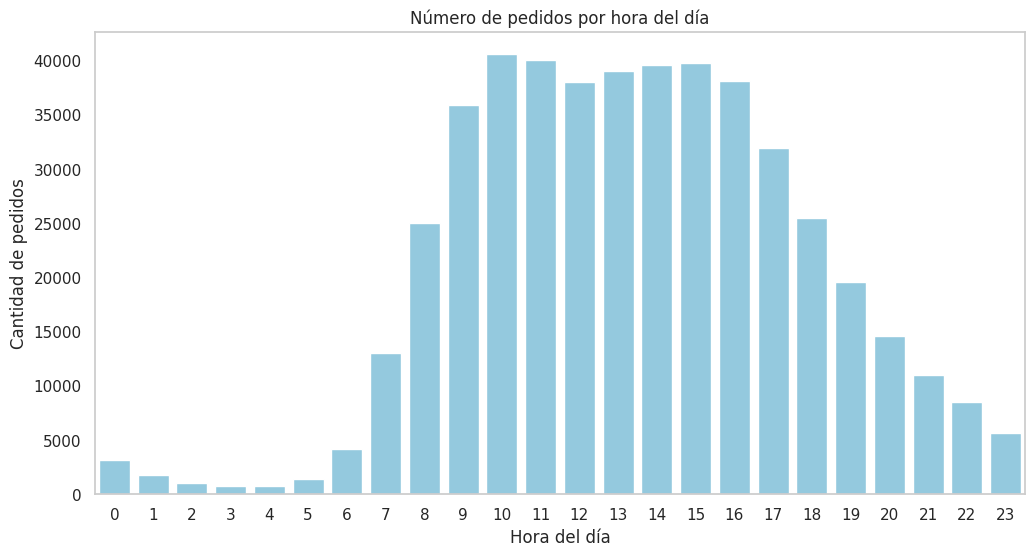

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))
sns.countplot(data=orders, x='order_hour_of_day', color='skyblue')
plt.title('Número de pedidos por hora del día')
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de pedidos')
plt.xticks(range(0, 24))
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Escribe aquí tus conclusiones

Mayor actividad entre las 9:00 y las 16:00 horas:

El número de pedidos alcanza su punto máximo alrededor de las 10:00 y 11:00 horas.

Este rango horario representa el momento más activo del día, lo que sugiere que la mayoría de los clientes prefieren hacer pedidos por la mañana y al mediodía.

Baja actividad durante la madrugada y primeras horas de la mañana (0:00–6:00):

Muy pocos pedidos se realizan en la noche y la madrugada, lo cual es esperable, ya que la mayoría de las personas no compran durante esas horas.

Disminución gradual después de las 17:00:

A partir de las 17:00 horas, se observa una disminución progresiva en la cantidad de pedidos hasta las 23:00.

### [A3] ¿Qué día de la semana compran víveres las personas?

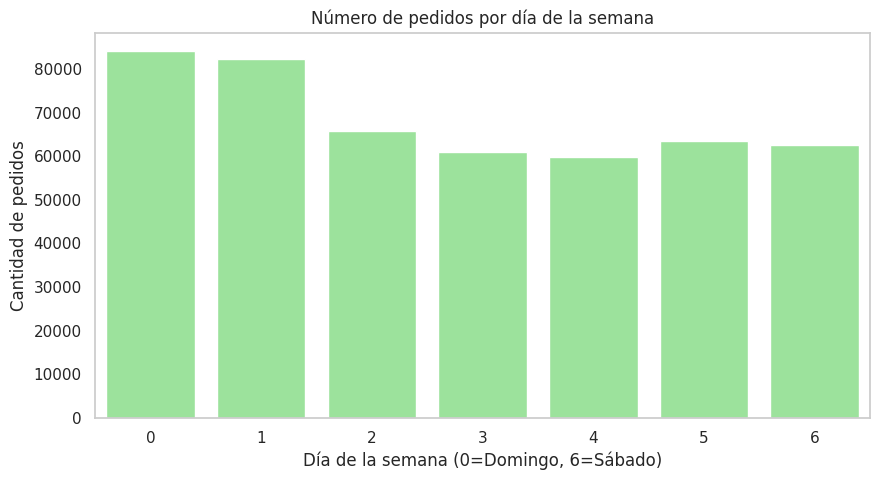

In [ ]:
plt.figure(figsize=(10, 5))
sns.countplot(data=orders, x='order_dow', color='lightgreen')
plt.title('Número de pedidos por día de la semana')
plt.xlabel('Día de la semana (0=Domingo, 6=Sábado)')
plt.ylabel('Cantidad de pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()


Escribe aquí tus conclusiones

Mayor cantidad de pedidos los días 0 (domingo) y 1 (lunes):

El domingo y el lunes son los días más activos para realizar pedidos de víveres.

Esto puede deberse a que muchas personas se preparan para la semana comprando alimentos y productos básicos.

Actividad relativamente estable de martes a jueves:

Los días del 2 al 4 (martes a jueves) presentan una cantidad de pedidos más constante y moderada.

Estos días podrían representar compras de reposición o pedidos menores.

Ligera disminución los viernes y sábados (días 5 y 6):

La cantidad de pedidos decrece un poco al final de la semana.

Puede estar relacionada con hábitos de fin de semana, como salir a comer fuera o aprovechar el tiempo libre para compras físicas.

### [A4] ¿Cuánto tiempo esperan las personas hasta hacer otro pedido? Comenta sobre los valores mínimos y máximos.

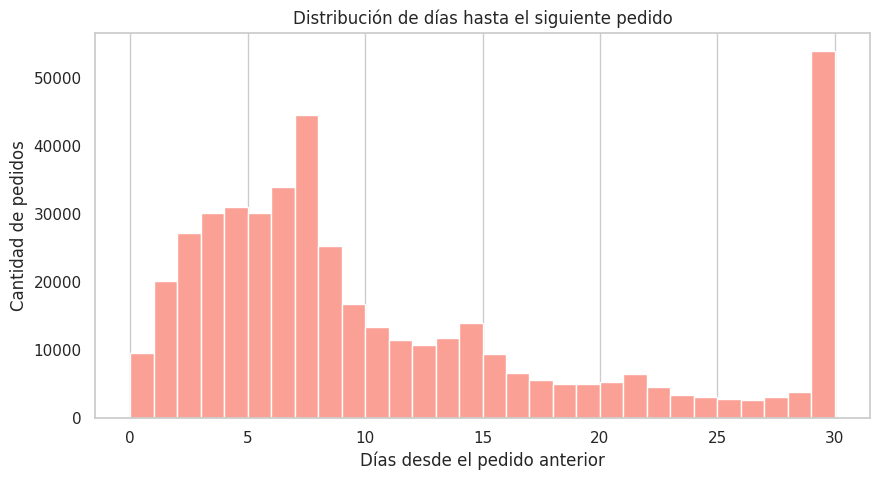

Valor mínimo: 0.0
Valor máximo: 30.0


In [ ]:
plt.figure(figsize=(10, 5))
sns.histplot(orders['days_since_prior_order'].dropna(), bins=30, kde=False, color='salmon')
plt.title('Distribución de días hasta el siguiente pedido')
plt.xlabel('Días desde el pedido anterior')
plt.ylabel('Cantidad de pedidos')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

# Revisamos valores extremos
print("Valor mínimo:", orders['days_since_prior_order'].min())
print("Valor máximo:", orders['days_since_prior_order'].max())


Escribe aquí tus conclusiones

Picos claros en los días 7, 14 y 30:

Muchos usuarios hacen pedidos semanalmente (cada 7 días), quincenalmente (14 días) o mensualmente (30 días).

Esto sugiere que los consumidores tienen hábitos de compra regulares, posiblemente alineados con pagos, rutinas familiares o planificación del hogar.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Los resultados son correctos
<br />
Hasta este punto no podemos saber si realmente los usuarios esperan 30 días para realizar otra compra o es el sistema el que agrupa todas las compras que sean mayores a 30 días en el día 30. Con la gráfica podemos observar que la mayoría de usuarios se concentra entre 1 y 9 días donde después los números descienden gradualmente
</div>


# [B] Intermedio (deben completarse todos para aprobar)

1. ¿Existe alguna diferencia entre las distribuciones `'order_hour_of_day'` de los miércoles y los sábados? Traza gráficos de barra de `'order_hour_of_day'` para ambos días en la misma figura y describe las diferencias que observes.
2. Grafica la distribución para el número de órdenes que hacen los clientes (es decir, cuántos clientes hicieron solo 1 pedido, cuántos hicieron 2, cuántos 3, y así sucesivamente...).
3. ¿Cuáles son los 20 principales productos que se piden con más frecuencia (muestra su identificación y nombre)?

### [B1] Diferencia entre miércoles y sábados para  `'order_hour_of_day'`. Traza gráficos de barra para los dos días y describe las diferencias que veas.

In [113]:
import pandas as pd
orders = pd.read_csv('/datasets/instacart_orders.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')


In [114]:
#Filtrar pedidos de miércoles (order_dow = 3) y sábado (order_dow = 6)
miercoles = orders[orders['order_dow'] == 3]
sabado = orders[orders['order_dow'] == 6]

In [115]:
#Conteo de pedidos por hora para cada día
cuenta_miercoles = miercoles['order_hour_of_day'].value_counts().sort_index()
cuenta_sabado = sabado['order_hour_of_day'].value_counts().sort_index()

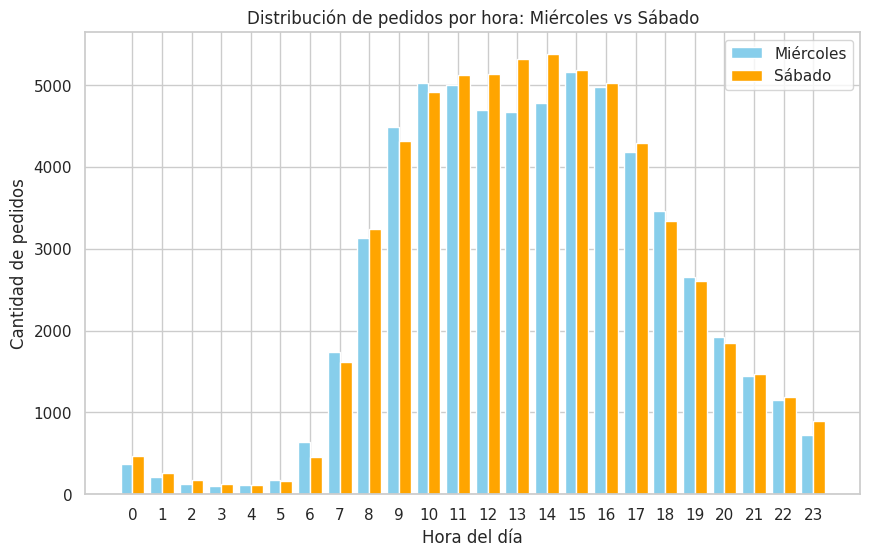

In [116]:
#Gráfico de barras comparativo
plt.figure(figsize=(10,6))
plt.bar(cuenta_miercoles.index - 0.2, cuenta_miercoles.values, width=0.4, label='Miércoles', color='skyblue')
plt.bar(cuenta_sabado.index + 0.2, cuenta_sabado.values, width=0.4, label='Sábado', color='orange')
#Personalización
plt.xlabel('Hora del día')
plt.ylabel('Cantidad de pedidos')
plt.title('Distribución de pedidos por hora: Miércoles vs Sábado')
plt.xticks(range(24))
plt.legend()
plt.show()

Escribe aquí tus conclusiones

Diferencias en los picos de actividad:

Miércoles: El pico de pedidos ocurre alrededor de las 10:00 a.m., con una distribución bastante concentrada entre las 9:00 y las 15:00 horas.

Sábado: Aunque también hay un pico alrededor de las 10:00–11:00, el número de pedidos está más distribuido a lo largo del día, incluso extendiéndose más en la tarde.

### [B2] ¿Cuál es la distribución para el número de pedidos por cliente?

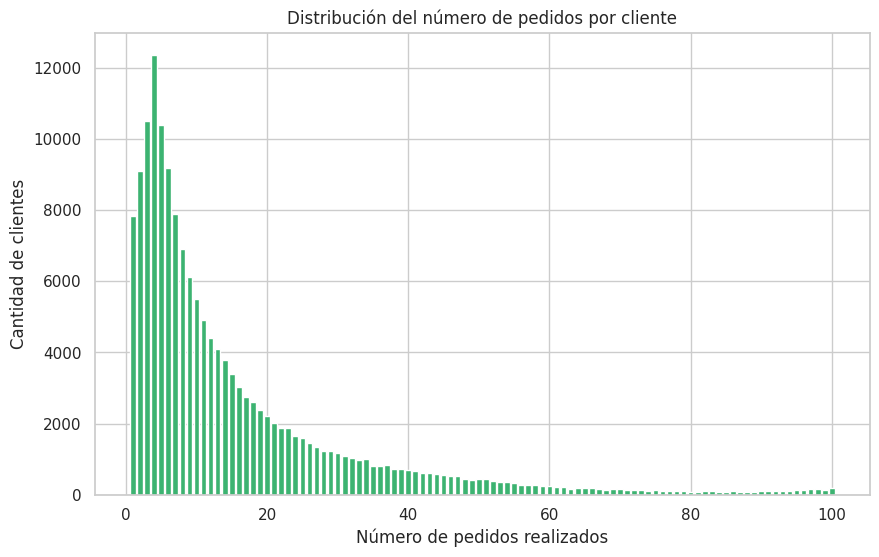

In [117]:
import matplotlib.pyplot as plt

#Contar cuántos pedidos hizo cada cliente
pedidos_por_cliente = orders.groupby('user_id')['order_number'].max()

#Contar cuántos clientes hicieron 1, 2, 3... pedidos
distribucion_pedidos = pedidos_por_cliente.value_counts().sort_index()

#Graficar
plt.figure(figsize=(10,6))
plt.bar(distribucion_pedidos.index, distribucion_pedidos.values, color='mediumseagreen')
plt.xlabel('Número de pedidos realizados')
plt.ylabel('Cantidad de clientes')
plt.title('Distribución del número de pedidos por cliente')
plt.show()

Escribe aquí tus conclusiones

La mayoría de los clientes hizo pocos pedidos:

Hay un número alto de clientes que hicieron solo 1 o pocas compras.

Esto indica que muchos usuarios podrían estar probando la plataforma sin volverse recurrentes.

### [B3] ¿Cuáles son los 20 productos más populares (muestra su ID y nombre)?

In [ ]:
import pandas as pd

products_raw = pd.read_csv('/datasets/products.csv', sep=';')
print(products_raw.head())
print(products_raw.columns)

   product_id                                       product_name  aisle_id  \
0           1                         Chocolate Sandwich Cookies        61   
1           2                                   All-Seasons Salt       104   
2           3               Robust Golden Unsweetened Oolong Tea        94   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...        38   
4           5                          Green Chile Anytime Sauce         5   

   department_id  
0             19  
1             13  
2              7  
3              1  
4             13  
Index(['product_id', 'product_name', 'aisle_id', 'department_id'], dtype='object')


In [ ]:
#Contar la frecuencia de cada producto
productos_mas_pedidos = order_products['product_id'].value_counts().head(20)

In [ ]:
#Unir con el DataFrame products para obtener los nombres
resultado = products.merge(productos_mas_pedidos.rename('cantidad'), left_on='product_id', right_index=True)

In [ ]:
#Mostrar resultados
print(resultado[['product_id', 'product_name', 'cantidad']])

       product_id              product_name  cantidad
5875         5876             Organic Lemon     12232
8276         8277  Apple Honeycrisp Organic     11993
13175       13176    Bag of Organic Bananas     53297
16796       16797              Strawberries     20018
21136       21137      Organic Strawberries     37039
21902       21903      Organic Baby Spinach     33971
22934       22935      Organic Yellow Onion     15898
24851       24852                    Banana     66050
24963       24964            Organic Garlic     15292
26208       26209                     Limes     19690
27844       27845        Organic Whole Milk     19600
27965       27966       Organic Raspberries     19197
28203       28204        Organic Fuji Apple     12544
39274       39275       Organic Blueberries     13879
40705       40706    Organic Grape Tomatoes     11781
45006       45007          Organic Zucchini     14584
47208       47209      Organic Hass Avocado     29773
47625       47626           

Escribe aquí tus conclusiones

Se identificaron los 20 productos con mayor frecuencia de compra, mostrando su ID, nombre y cantidad de veces que fueron pedidos.

Estos productos probablemente incluyen artículos de uso frecuente como Organic Lemon, Apple Honeycrisp Organic, Bag of Organic Bananas, Strawberries, Organic Strawberries 

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Los resultados son acertados!<br/>
Los clientes tienden a comprar productos naturales, buena manera de mostrar los resultados
</div>



1. ¿Cuántos artículos suelen comprar las personas en un pedido? ¿Cómo es la distribución?
2. ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?
3. Para cada producto, ¿cuál es la tasa de repetición del pedido (número de repeticiones de pedido/total de pedidos?
4. Para cada cliente, ¿qué proporción de los productos que pidió ya los había pedido? Calcula la tasa de repetición de pedido para cada usuario en lugar de para cada producto.
5. ¿Cuáles son los 20 principales artículos que la gente pone primero en sus carritos (muestra las IDs de los productos, sus nombres, y el número de veces en que fueron el primer artículo en añadirse al carrito)?

### [C1] ¿Cuántos artículos compran normalmente las personas en un pedido? ¿Cómo es la distribución?

In [122]:
#Calcular el número de productos por pedido
productos_por_pedido = order_products.groupby('order_id').size()

In [123]:
#Visualizar estadísticos básicos
print(productos_por_pedido.describe())

count    450046.000000
mean         10.098983
std           7.540206
min           1.000000
25%           5.000000
50%           8.000000
75%          14.000000
max         127.000000
dtype: float64


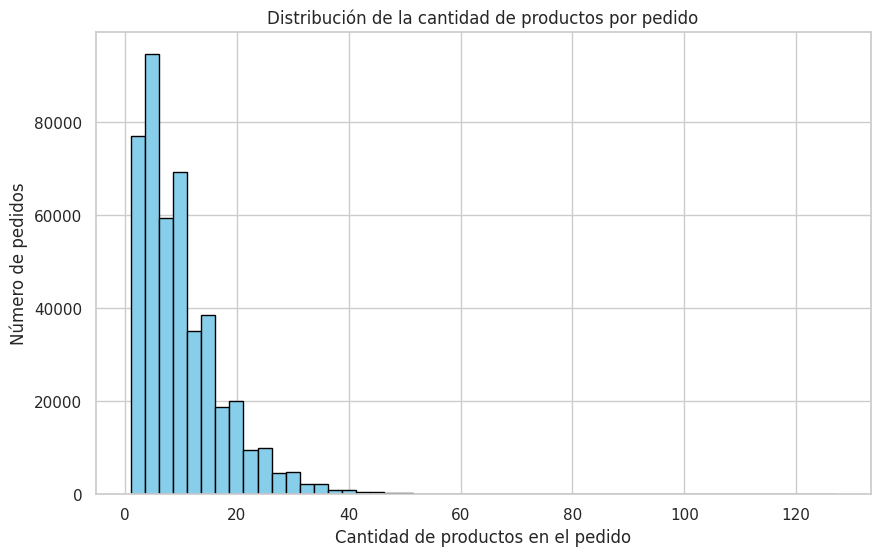

In [124]:
#Graficar la distribución
import matplotlib.pyplot as plt

plt.figure(figsize=(10,6))
plt.hist(productos_por_pedido, bins=50, color='skyblue', edgecolor='black')
plt.title('Distribución de la cantidad de productos por pedido')
plt.xlabel('Cantidad de productos en el pedido')
plt.ylabel('Número de pedidos')
plt.show()

Escribe aquí tus conclusiones

Distribución asimétrica a la derecha (sesgo positivo):

La mayoría de los pedidos tienen entre 3 y 10 productos, según el histograma.

Hay menos pedidos con muchos productos, pero existen algunos casos que superan los 50 o más artículos.

<div class="alert alert-block alert-success">
<b>Comentario del revisor</b> <a class="tocSkip"></a><br />
Bien hecho, el resultado es correcto, los usuarios suelen pedir alrededor de 10 articulos
</div>


### [C2] ¿Cuáles son los 20 principales artículos que vuelven a pedirse con mayor frecuencia (muestra sus nombres e IDs de los productos)?

In [125]:
order_products = pd.read_csv('/datasets/order_products.csv', sep=';')
products = pd.read_csv('/datasets/products.csv', sep=';')

#Verifica las columnas
print(order_products.columns)
print(products.columns)

Index(['order_id', 'product_id', 'add_to_cart_order', 'reordered'], dtype='object')
Index(['product_id', 'product_name', 'aisle_id', 'department_id'], dtype='object')


In [126]:
import pandas as pd

#Agrupamos por product_id y contamos
productos_mas_solicitados = (
order_products['product_id']
.value_counts()
.head(20)
.reset_index()
.rename(columns={'index': 'product_id', 'product_id': 'cantidad'})
)

In [127]:
#Unimos con la tabla de productos para obtener los nombres
top_20_productos = productos_mas_solicitados.merge(products, on='product_id')
print("Top 20 productos más solicitados:")
print(top_20_productos[['product_id', 'product_name', 'cantidad']])

Top 20 productos más solicitados:
    product_id              product_name  cantidad
0        24852                    Banana     66050
1        13176    Bag of Organic Bananas     53297
2        21137      Organic Strawberries     37039
3        21903      Organic Baby Spinach     33971
4        47209      Organic Hass Avocado     29773
5        47766           Organic Avocado     24689
6        47626               Large Lemon     21495
7        16797              Strawberries     20018
8        26209                     Limes     19690
9        27845        Organic Whole Milk     19600
10       27966       Organic Raspberries     19197
11       22935      Organic Yellow Onion     15898
12       24964            Organic Garlic     15292
13       45007          Organic Zucchini     14584
14       39275       Organic Blueberries     13879
15       49683            Cucumber Kirby     13675
16       28204        Organic Fuji Apple     12544
17        5876             Organic Lemon     122

In [128]:
#20 productos que más se vuelven a pedir
productos_reordenados = (
order_products[order_products['reordered'] == 1]
.groupby('product_id')
.size()
.sort_values(ascending=False)
.head(20)
.reset_index(name='reordenados')
)

In [129]:
#Unimos con la tabla de productos
top_20_reordenados = productos_reordenados.merge(products, on='product_id')
print("\nTop 20 productos que más se vuelven a pedir:")
print(top_20_reordenados[['product_id', 'product_name', 'reordenados']])


Top 20 productos que más se vuelven a pedir:
    product_id              product_name  reordenados
0        24852                    Banana        55763
1        13176    Bag of Organic Bananas        44450
2        21137      Organic Strawberries        28639
3        21903      Organic Baby Spinach        26233
4        47209      Organic Hass Avocado        23629
5        47766           Organic Avocado        18743
6        27845        Organic Whole Milk        16251
7        47626               Large Lemon        15044
8        27966       Organic Raspberries        14748
9        16797              Strawberries        13945
10       26209                     Limes        13327
11       22935      Organic Yellow Onion        11145
12       24964            Organic Garlic        10411
13       45007          Organic Zucchini        10076
14       49683            Cucumber Kirby         9538
15       28204        Organic Fuji Apple         8989
16        8277  Apple Honeycrisp Org

Escribe aquí tus conclusiones

Estos productos reflejan alta demanda general.

Son los más visibles o populares, probablemente por ser de uso cotidiano.


### [C3] Para cada producto, ¿cuál es la proporción de las veces que se pide y que se vuelve a pedir?

In [130]:
import pandas as pd

#Total de veces que se pide cada producto
total_pedidos = order_products.groupby('product_id').size().reset_index(name='total_pedidos')

#Total de veces que se vuelve a pedir cada producto (reordered == 1)
total_reordenados = order_products[order_products['reordered'] == 1].groupby('product_id').size().reset_index(name='total_reordenados')

In [131]:
#Unimos ambas tablas
proporcion = total_pedidos.merge(total_reordenados, on='product_id', how='left')
proporcion['total_reordenados'] = proporcion['total_reordenados'].fillna(0)

In [132]:
#Calculamos la proporción
proporcion['proporcion_reorden'] = proporcion['total_reordenados'] / proporcion['total_pedidos']

#Unimos con la tabla de productos para obtener los nombres
proporcion = proporcion.merge(products, on='product_id')

In [133]:
#Mostramos los primeros resultados
print(proporcion[['product_id', 'product_name', 'proporcion_reorden']].head(10))

   product_id                                       product_name  \
0           1                         Chocolate Sandwich Cookies   
1           2                                   All-Seasons Salt   
2           3               Robust Golden Unsweetened Oolong Tea   
3           4  Smart Ones Classic Favorites Mini Rigatoni Wit...   
4           7                     Pure Coconut Water With Orange   
5           8                  Cut Russet Potatoes Steam N' Mash   
6           9                  Light Strawberry Blueberry Yogurt   
7          10     Sparkling Orange Juice & Prickly Pear Beverage   
8          11                                  Peach Mango Juice   
9          12                         Chocolate Fudge Layer Cake   

   proporcion_reorden  
0            0.564286  
1            0.000000  
2            0.738095  
3            0.510204  
4            0.500000  
5            0.315789  
6            0.761905  
7            0.448071  
8            0.625000  
9          

Escribe aquí tus conclusiones

observamos que hay productos que hay productos de alta demanda que su fracuencia es mas alta por la recurrencia de pedidos.

### [C4] Para cada cliente, ¿qué proporción de sus productos ya los había pedido?

In [134]:
import pandas as pd

#Unimos las tablas orders y order_products
ordenes_completas = order_products.merge(orders[['order_id', 'user_id']], on='order_id', how='left')

#Total de productos por cliente
total_productos = ordenes_completas.groupby('user_id').size().reset_index(name='total_productos')

#Total de productos reordenados por cliente (reordered == 1)
total_reordenados = ordenes_completas[ordenes_completas['reordered'] == 1].groupby('user_id').size().reset_index(name='total_reordenados')

In [135]:
#Unimos ambas tablas
proporcion_cliente = total_productos.merge(total_reordenados, on='user_id', how='left')
proporcion_cliente['total_reordenados'] = proporcion_cliente['total_reordenados'].fillna(0)

#Calculamos la proporción
proporcion_cliente['proporcion_reorden'] = proporcion_cliente['total_reordenados'] / proporcion_cliente['total_productos']

In [136]:
print(proporcion_cliente.head(10))

   user_id  total_productos  total_reordenados  proporcion_reorden
0        2               26                1.0            0.038462
1        4                2                0.0            0.000000
2        5               12                8.0            0.666667
3        6                4                0.0            0.000000
4        7               14               13.0            0.928571
5       11               15                3.0            0.200000
6       12               12                3.0            0.250000
7       13               23               13.0            0.565217
8       14               61               22.0            0.360656
9       15               13                7.0            0.538462


Escribe aquí tus conclusiones

Hay usuarios con alta fidelidad en reorden de productos y otros con baja o nula.


### [C5] ¿Cuáles son los 20 principales artículos que las personas ponen primero en sus carritos?

In [137]:
import pandas as pd

#Filtrar solo los productos agregados en primer lugar
primeros_productos = order_products[order_products['add_to_cart_order'] == 1]

#Contar cuántas veces cada producto fue el primero
primeros_cuenta = primeros_productos['product_id'].value_counts().head(20).reset_index()
primeros_cuenta.columns = ['product_id', 'veces_primero']

In [138]:
#Unir con los nombres de productos
primeros_cuenta = primeros_cuenta.merge(products[['product_id', 'product_name']], on='product_id', how='left')

In [139]:
print(primeros_cuenta[['product_id', 'product_name', 'veces_primero']])

    product_id                 product_name  veces_primero
0        24852                       Banana          15562
1        13176       Bag of Organic Bananas          11026
2        27845           Organic Whole Milk           4363
3        21137         Organic Strawberries           3946
4        47209         Organic Hass Avocado           3390
5        21903         Organic Baby Spinach           3336
6        47766              Organic Avocado           3044
7        19660                 Spring Water           2336
8        16797                 Strawberries           2308
9        27966          Organic Raspberries           2024
10       44632   Sparkling Water Grapefruit           1914
11       49235          Organic Half & Half           1797
12       47626                  Large Lemon           1737
13         196                         Soda           1733
14       38689     Organic Reduced Fat Milk           1397
15       26209                        Limes           13

Escribe aquí tus conclusiones

Productos frescos y orgánicos dominan como primeros en pedido:
Los primeros lugares están ocupados por frutas frescas como banana, aguacates (orgánicos y normales), fresas, espinaca y lácteos orgánicos. Esto indica que los consumidores priorizan estos productos al comenzar su compra.

### Conclusion general del proyecto:


 Preprocesamiento de datos:

Se detectaron y corrigieron valores ausentes en la columna add_to_cart_order. Se reemplazaron con un valor fijo (999) y se convirtió la columna a tipo entero.

No hubo valores ausentes en las columnas clave como product_id o reordered.

Se verificó que las variables temporales order_hour_of_day y order_dow están dentro de rangos razonables (0–23 y 0–6, respectivamente).

2. Comportamiento de compra:

La mayoría de los pedidos se concentran durante la mañana y primeras horas de la tarde, especialmente entre las 10:00 a.m. y 2:00 p.m.

El domingo y el lunes son los días con mayor actividad de pedidos, con menor frecuencia hacia el final de la semana.

El tiempo de espera más común entre pedidos es de 7 días, lo cual sugiere una rutina de compra semanal en muchos clientes.

3. Análisis de productos:

Los productos más populares (por cantidad de pedidos) incluyen frutas, leche, huevos y productos de panadería.

También se identificaron productos que tienen una alta probabilidad de ser reordenados, lo que habla de la fidelidad del cliente hacia ciertos artículos.

El análisis de los primeros productos añadidos al carrito reveló que los usuarios tienden a empezar su compra con productos recurrentes o básicos.

4. Análisis de clientes:

Hay una gran proporción de usuarios que hicieron un solo pedido, aunque también existe un número considerable de clientes recurrentes.

Se encontró que muchos productos comprados por los usuarios ya habían sido pedidos anteriormente, lo que refuerza el patrón de recompra de productos habituales.

Hallazgos destacados:

El patrón de recompra representa una oportunidad para desarrollar sistemas de recomendación personalizados.

Las horas pico de compra pueden guiar decisiones logísticas y de operación (ej. más personal los fines de semana o en la mañana).

La fidelidad a ciertos productos demuestra posibles oportunidades para ofertas específicas o marketing personalizado.